### Notebook for test and demonstration of Ballistic Tables

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from mad.utils.ballistic_tables import load_ballistic_df
from mad.utils.plotters import plot_ballistic_range_table_gamma, plot_ballistic_range_table

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

A steely-eyed missile man would have noticed our Planet objects *do not spin*.

It has some drawbacks as we cannot fully mimic real situations (we lost some speed dearly needed to put things in orbit) but it has one main advantage: we do not care in what directon we are launching. Polar orbits are just the same as equatorial orbits. We can do even better: if we know the charcteristic of a ballistic object (mass, reference radius, drag coefficient) we can precompute its trajectory from any point in space, velocity and attitude and now where it will land at the end of the trajectory.

This can be then used in a guidance system to know where and at what speed fling a ballistic warhead to reach its target, for example.

Ballistic tables are pre-computed with the script `scripts/tabulate_ballistic_range.py` and the different configurations are in `scripts/ranges.cfgs.py`. See these files for a more detailed explanation on how to use them.

The resulting tables are saved in the `tables/` folder. 

In [10]:
# Let's load 2 tables, for the V1 missile and the B53 nuclear Warhead.
V1_table_name = "V1"
B53_table_name = "B53_warhead_demo"

df = load_ballistic_df(V1_table_name)
df2 = load_ballistic_df(B53_table_name)

# Tabulated values according to altitude, velocity, gamma, and obtained range.
df

,altitude_m,velocity_m_s,gamma_rad,range_rad,range_km,altitude_km,gamma_deg
0,100.0,100.0,-0.349066,0.000044,0.280190,0.10,-20.0
1,100.0,100.0,-0.314159,0.000045,0.283581,0.10,-18.0
2,100.0,100.0,-0.279253,0.000045,0.286627,0.10,-16.0
3,100.0,100.0,-0.244346,0.000045,0.289324,0.10,-14.0
4,100.0,100.0,-0.209440,0.000046,0.291669,0.10,-12.0
...,...,...,...,...,...,...,...
3595,950.0,190.0,0.174533,0.000498,3.170358,0.95,10.0
3596,950.0,190.0,0.209440,0.000520,3.314789,0.95,12.0
3597,950.0,190.0,0.244346,0.000542,3.452195,0.95,14.0
3598,950.0,190.0,0.279253,0.000562,3.582095,0.95,16.0


In [11]:
df2["altitude_km"].unique()

array([  5., 105., 205., 305., 405.])

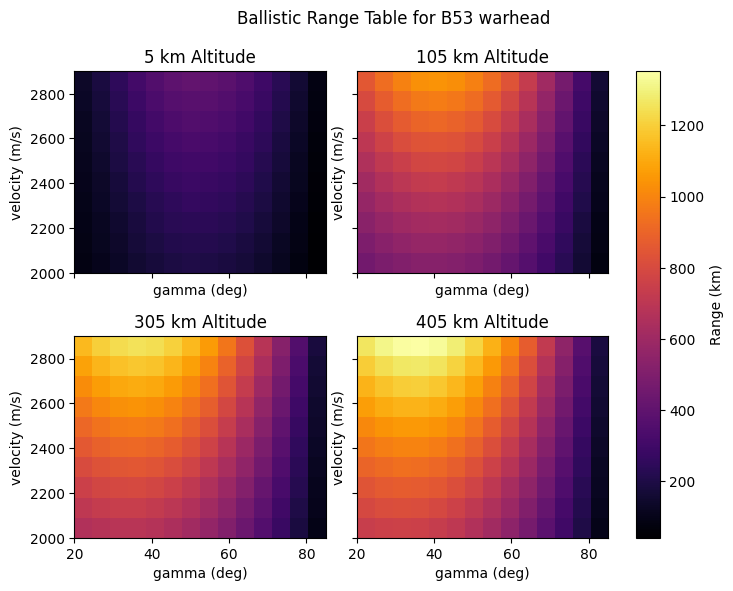

In [13]:
selected_altitudes_km = [5, 105, 305, 405]  # km
plot_ballistic_range_table(df2, selected_altitudes_km, "B53 warhead")

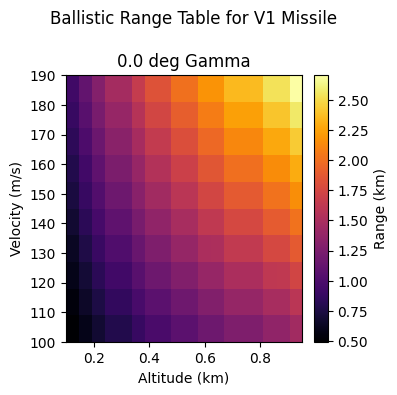

In [14]:
selected_gamma = 0.0 # deg

plot_ballistic_range_table_gamma(df, selected_gamma=0.0, table_name="V1 Missile");